In [70]:
# Input Image
# SET PYTHONPATH to the parent directory 
import os
import sys
import torch
import matplotlib.pyplot as plt
plt.rc('text', usetex=True)
from einops import rearrange
if os.path.abspath("..") not in sys.path:
    sys.path.append(os.path.abspath(".."))


import torch 
import numpy as np
from typing import List
from scipy.linalg import dft
from einops import rearrange, repeat

def init_weights(in_channels: int, out_channels: int, orders: List[int], ring_count: int):
    """
    Initializes the dict of weights

    Args:

        in_channels: input channels
        out_channels: output channels
        max_order: maximum rotation order from input and output
        ring_count (int): Number of rings for calculating the basis
    Returns:
        weights_dict: initialized dict of weights

    """
    weights = torch.zeros((len(orders), ring_count, in_channels, out_channels),
                            dtype=torch.get_default_dtype())
    for idx, _ in enumerate(orders):
        sh = [ring_count, in_channels, out_channels]
        # Initializes the weights using initialization method of He
        stddev = 0.4 * np.sqrt(2.0 / np.prod(sh[:3]))
        weights[idx] = torch.normal(torch.zeros(*sh), stddev)
    # Flat input & output channels
    return weights.view((len(orders), ring_count, in_channels * out_channels))

def get_angle_samples_count(kernel_size):
    return int(np.maximum(np.ceil(np.pi * kernel_size), 101))

def get_l2_neighbors(center, shape):
    lin = np.arange(shape) + 0.5
    jj, ii = np.meshgrid(lin, lin)
    ii = ii - center[1]
    jj = jj - center[0]
    return np.vstack((np.reshape(ii, -1), np.reshape(jj, -1)))

def get_interpolation_weights(fs, m, n_rings, angle_samples):
    """
    Used to construct the steerable filters using Radial basis functions.
    The filters are constructed on the patches of n_rings using Gaussian
    interpolation. (Code adapted from the tf code of Worrall et al., CVPR, 2017)

    Args:
        fs (int): filter size for the H-net convolutional layer
        m (int): max. rotation order for the steerable filters
        n_rings (int): No. of rings for the steerable filters
        angle_samples (int): No. of angle samples

    Returns:
        norm_weights (numpy): contains normalized weights for interpolation
        using the steerable filters
    """

    mid = int(np.floor(fs / 2))
    # Variance of Gaussian resampling
    std_gauss = (mid / n_rings) / 2
    # We define below radii up to n_rings-0.5 (as in Worrall et al, CVPR 2017)
    radii = np.linspace(m != 0, mid - 2 * std_gauss, n_rings)
    # We define pixel centers to be at positions 0.5
    center_pt = np.asarray([fs, fs]) / 2.

    # Extracting the set of angles to be sampled

    # Choosing the sampling locations for the rings
    lin = (2 * np.pi * np.arange(angle_samples)) / angle_samples
    ring_locations = np.vstack([-np.sin(lin), np.cos(lin)])

    # Create interpolation coefficient coordinates
    coords = get_l2_neighbors(center_pt, fs)

    # getting samples based on the chosen center_pt and the coords
    radii = radii[:, np.newaxis, np.newaxis, np.newaxis]
    ring_locations = ring_locations[np.newaxis, :, :, np.newaxis]
    diff = radii * ring_locations - coords[np.newaxis, :, np.newaxis, :]
    dist2 = np.sum(diff ** 2, axis=1)

    # Convert distances to weightings
    weights = np.exp(-0.5 * dist2 / (std_gauss ** 2))  # For bandwidth of 0.5

    # Normalizing the weights to calibrate the different steerable filters
    norm = np.sum(weights,
                    axis=2,
                    keepdims=True)
    assert np.all(norm != 0), "Normalizing by zero weights"
    return np.divide(weights,
                        norm,
                        where=(norm != 0)
                        )

def get_low_pass_filter(kernel_size, orders, n_rings):
    N = get_angle_samples_count(kernel_size)
    weights2filter_sampler = []
    for order in orders:
        weights = get_interpolation_weights(kernel_size,
                                            m=order,
                                            n_rings=n_rings,
                                            angle_samples=N)
        low_pass_filter = np.dot(dft(N)[order, :], weights).T
        weights2filter_sampler.append(
                torch.from_numpy(low_pass_filter))
    return torch.stack(weights2filter_sampler)

In [71]:
in_channels = 1 
out_channels = 2
ring_count = 3
kernel_size = 15
orders = [0, 0, 0, 1, 2 ,1, 3, 2, 4, -1, -2, -1, -3, -2, -4]
pos_orders = len([0, 0, 0, 1, 2 ,1, 3, 2, 4]) 
neg_orders = len(orders) - pos_orders


radial_weights = init_weights(in_channels, 
                              out_channels,
                              orders=orders,
                              ring_count=ring_count)
angular_part = get_low_pass_filter(kernel_size,
                                   orders=orders,
                                   n_rings=ring_count)
# Construct the filters
filters = rearrange(torch.matmul(angular_part, radial_weights.to(torch.complex128)),
              pattern="o (h w) (ic oc) -> o oc ic h w",
              h=kernel_size,
              w=kernel_size,
              ic=in_channels,
              oc=out_channels)

In [ ]:
# plot the filters
import numpy as np
import colorsys

def complex_to_rgb(Z):
    mag = np.abs(Z)
    phase = np.angle(Z)
    norm_mag = mag / mag.max()
    
    hsv = np.zeros(Z.shape + (3,))
    hsv[..., 0] = (phase + np.pi) / (2*np.pi)   # hue
    hsv[..., 1] = 1.0                           # saturation
    hsv[..., 2] = norm_mag                      # value
    
    rgb = np.zeros_like(hsv)
    for i in range(Z.shape[0]):
        for j in range(Z.shape[1]):
            rgb[i,j] = colorsys.hsv_to_rgb(*hsv[i,j])
    return rgb

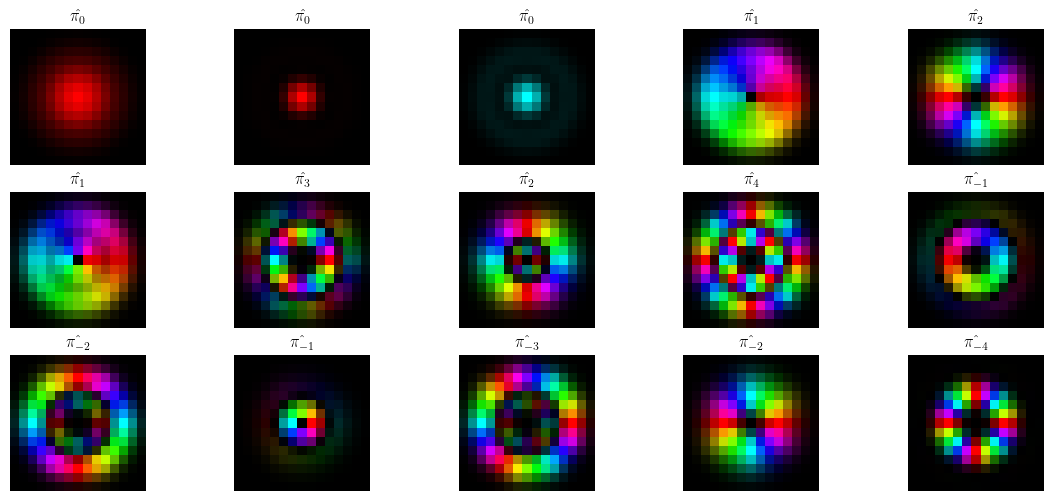

In [74]:
import matplotlib.pyplot as plt
# Plot all the filters
fig, axes = plt.subplots(3, 5, figsize=(14, 6)) 
for i, ax in enumerate(axes.flat):
    if i < filters.shape[0]:
        filter = filters[i][0][0].detach()
        ax.imshow(complex_to_rgb((filter).numpy()))
        ax.set_title(f'$\hat{{\pi_{{{orders[i]}}}}}$')
    ax.axis('off')

In [75]:
# Testing images
import torch 
from torchvision import transforms
from hippy2d.utils import get_testing_img, get_default_complex
# Set default to double precision
torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Pretend complex img of type 0 
test_img = get_testing_img(rgb=False)
test_img = transforms.ToTensor()(test_img).to(dtype=torch.float64)
rotated_img = torch.rot90(test_img, 1, [1, 2])
# 
test_rgb_img = get_testing_img(rgb=True)
test_rgb_img = transforms.ToTensor()(test_rgb_img).to(dtype=torch.float64)
rotated_rgb_img = torch.rot90(test_rgb_img, 1, [1, 2])

test_c_img = torch.view_as_complex(rearrange(test_rgb_img[:2], pattern="c h w -> 1 1 h w c").contiguous())
rot_test_c_img = torch.view_as_complex(rearrange(rotated_rgb_img[:2], pattern="c h w ->1 1 h w c").contiguous())

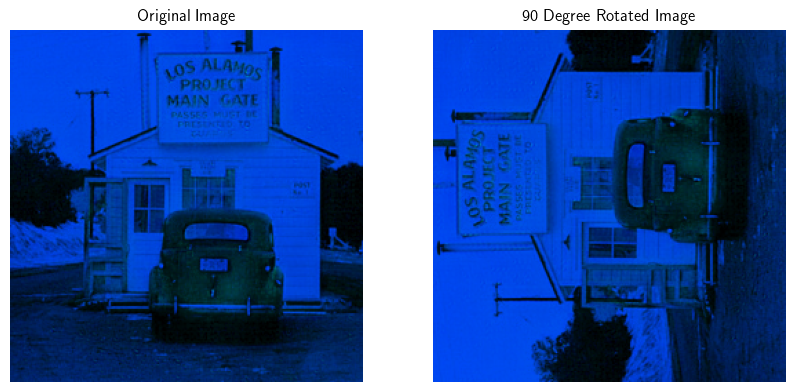

In [76]:
# Plot the images
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(complex_to_rgb(test_c_img[0][0].numpy()))
plt.title("Original Image")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(complex_to_rgb(rot_test_c_img[0][0].numpy()))
plt.title("90 Degree Rotated Image",)
plt.axis('off')
plt.show()



In [77]:
_filters = rearrange(filters, 'o oc ic h w -> (o oc) ic h w')
output = torch.conv2d(input=test_c_img,
                      weight=_filters)
#output = rearrange(output, 'b (m out) h w -> b m out h w')
output_rot = torch.conv2d(input=rot_test_c_img,
                          weight=_filters)
output = rearrange(output, 'b (m out) h w -> b m out h w', m=len(orders))[0]
output_rot = rearrange(output_rot, 'b (m out) h w -> b m out h w', m=len(orders))[0]


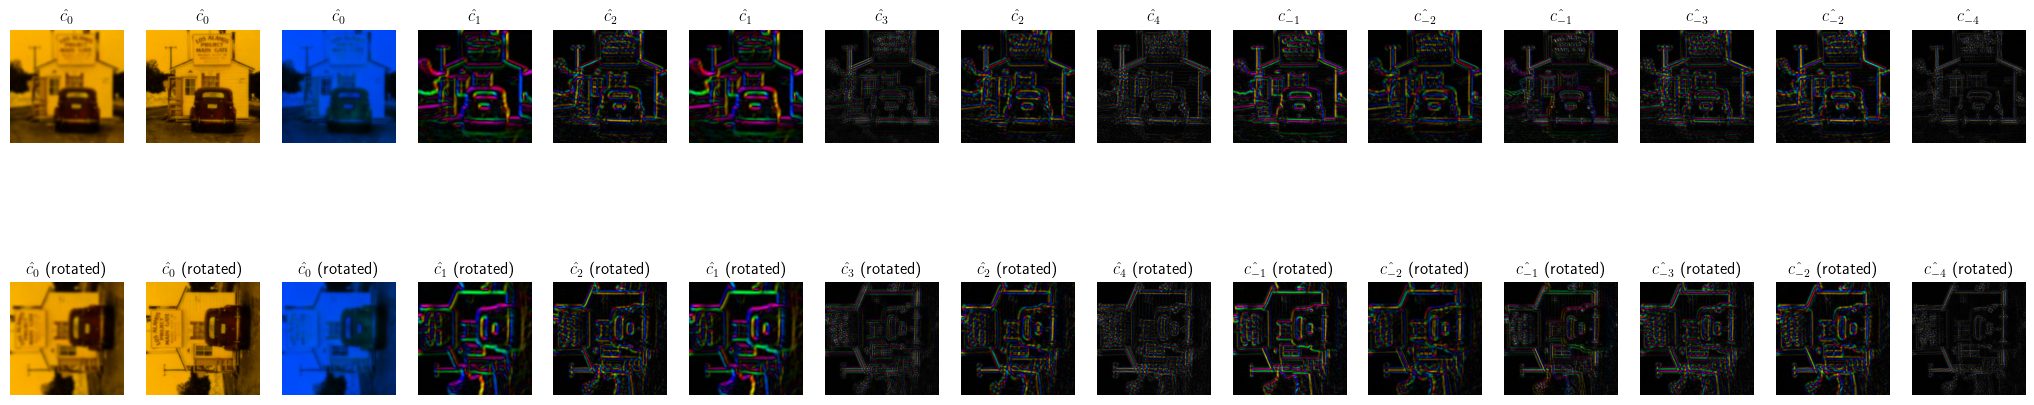

In [78]:
# plot the outputs in complex
OUTPUT_CHANNEL = 0
# plot all the channels
fig, axs = plt.subplots(2, output.shape[0], figsize=(26, 6))

for idx, ax in enumerate(axs[0].flat):
        ax.imshow(complex_to_rgb(output[idx][OUTPUT_CHANNEL].detach().numpy()), cmap='hsv')
        ax.axis('off')
        ax.set_title(f'$\hat{{c_{{{orders[idx]}}}}}$')
for idx, ax in enumerate(axs[1].flat):
        ax.imshow(complex_to_rgb(output_rot[idx][OUTPUT_CHANNEL].detach().numpy()), cmap='hsv')
        ax.axis('off')
        ax.set_title(f'$\hat{{c_{{{orders[idx]}}}}}$ (rotated)')

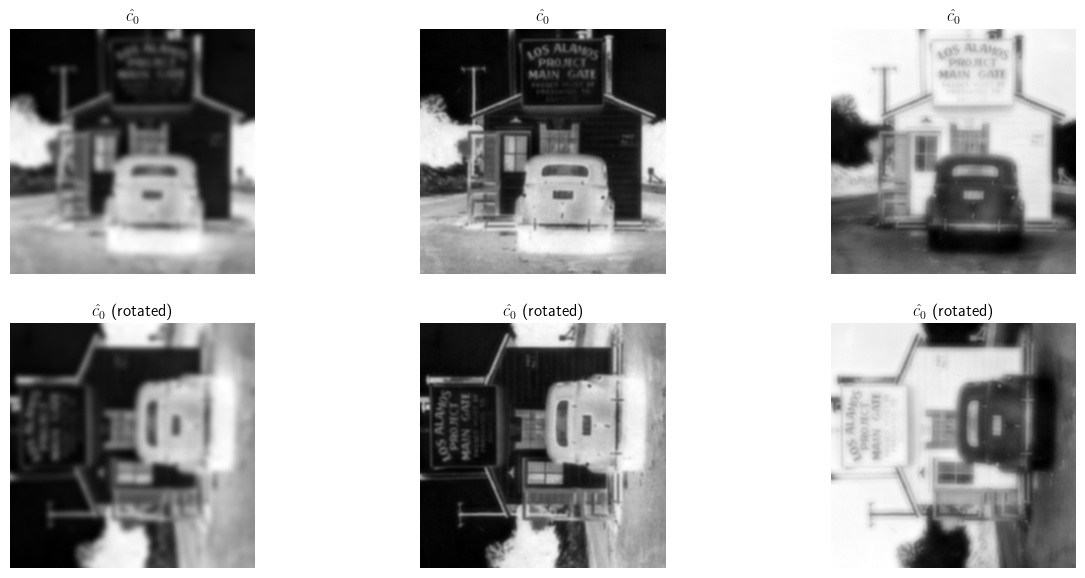

In [79]:
symmetry = output[:3].real
symmetry_rot = output_rot[:3].real
# plot the symmertry channels 
fig, axs = plt.subplots(2, symmetry.shape[0], figsize=(15, 7))
for idx, ax in enumerate(axs[0].flat):
        ax.imshow(symmetry[idx][OUTPUT_CHANNEL],cmap='gray')
        ax.axis('off')
        ax.set_title(f'$\hat{{c_{{{orders[idx]}}}}}$')
for idx, ax in enumerate(axs[1].flat):
        ax.imshow(symmetry_rot[idx][OUTPUT_CHANNEL],cmap='gray')
        ax.axis('off')
        ax.set_title(f'$\hat{{c_{{{orders[idx]}}}}}$ (rotated)')

# Assert the symmetry channels are rotation invariant
assert torch.allclose(symmetry, torch.rot90(symmetry_rot, k=-1,dims=[-2, -1])), "Symmetry channels are not rotation invariant"

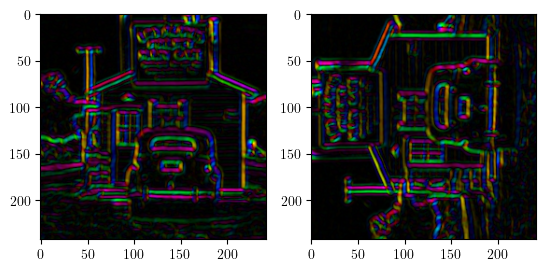

In [80]:
norm_factor = output[pos_orders]
norm_factor_rot = output_rot[pos_orders]
moments = output[3:pos_orders]
moments_rot = output_rot[3:pos_orders]
plt.subplot(1, 2, 1)
plt.imshow(complex_to_rgb(norm_factor[OUTPUT_CHANNEL].detach().numpy()))
plt.subplot(1, 2, 2)
plt.imshow(complex_to_rgb(norm_factor_rot[OUTPUT_CHANNEL].detach().numpy()))

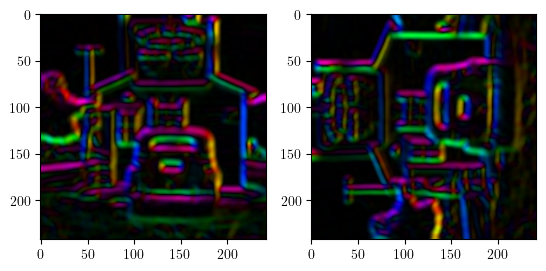

In [81]:
neg_norm_factor = output[3]
neg_norm_factor_rot = output_rot[3]
neg_moments = output[pos_orders:]
neg_moments_rot = output_rot[pos_orders:]
plt.subplot(1, 2, 1)
plt.imshow(complex_to_rgb(neg_norm_factor[OUTPUT_CHANNEL].detach().numpy()))
plt.subplot(1, 2, 2)
plt.imshow(complex_to_rgb(neg_norm_factor_rot[OUTPUT_CHANNEL].detach().numpy()))

In [82]:

from hippy2d.flexibleconv2d import complex_power_moivre
# plot the norm factor

exp = torch.tensor(orders[3:pos_orders])

# Replace this with non-exp normalization
neg_invariants = neg_moments * (neg_norm_factor ** exp[:,None, None, None])
neg_invariants_rot = neg_moments_rot * (neg_norm_factor_rot ** exp[:, None, None, None])

# Invariants with copy 
neg_invariants_copy = moments * torch.view_as_complex(
    complex_power_moivre(torch.view_as_real(norm_factor),
                                       exp[:, None, None, None],
                                       magnitude_func="copy")
)
neg_invariants_rot_copy = moments_rot * torch.view_as_complex(
    complex_power_moivre(torch.view_as_real(norm_factor_rot),
                                       exp[:, None, None, None],
                                       magnitude_func="copy")
)


from hippy2d.flexibleconv2d import complex_power_moivre
# plot the norm factor

exp = torch.tensor(orders[3:pos_orders])

# Positive order invariants
# Replace this with non-exp normalization
invariants = moments * (norm_factor ** exp[:,None, None, None])
invariants_rot = moments_rot * (norm_factor_rot ** exp[:, None, None, None])

# Invariants with copy 
invariants_copy = moments * torch.view_as_complex(
    complex_power_moivre(torch.view_as_real(norm_factor),
                                       exp[:, None, None, None],
                                       magnitude_func="copy")
)
invariants_rot_copy = moments_rot * torch.view_as_complex(
    complex_power_moivre(torch.view_as_real(norm_factor_rot),
                                       exp[:, None, None, None],
                                       magnitude_func="copy")
)



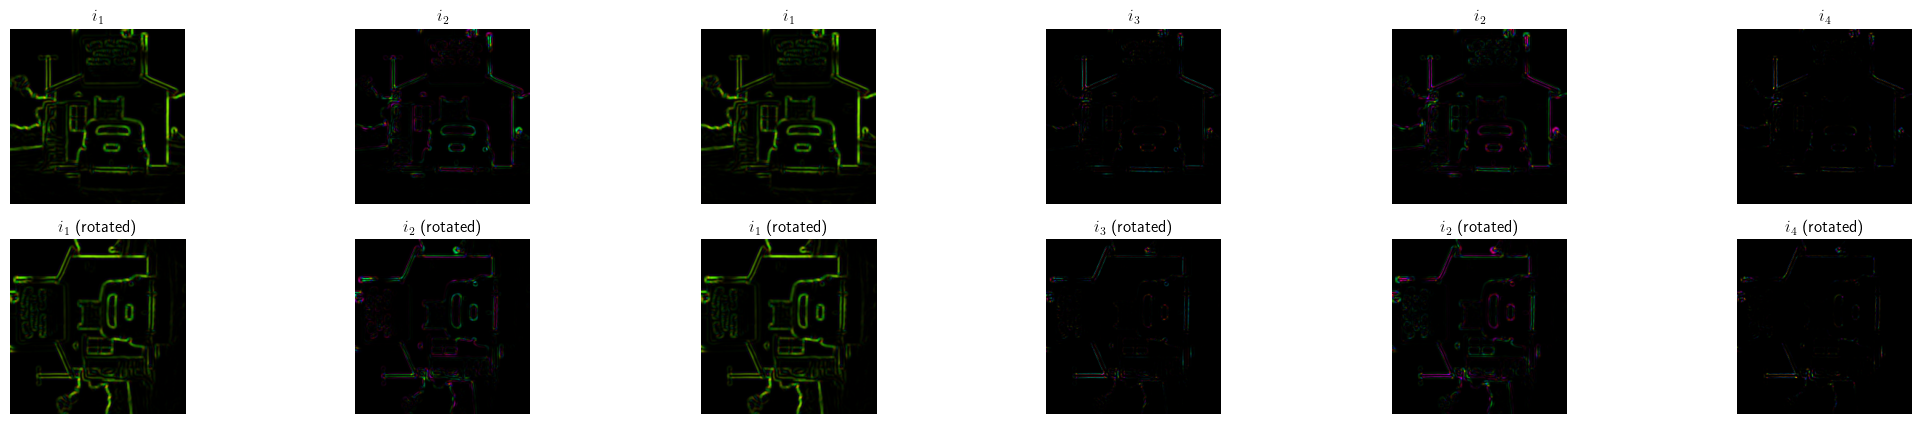

In [83]:
# Positive order invariants

fig, axs = plt.subplots(2, invariants.shape[0], figsize=(26, 5))
for idx, ax in enumerate(axs[0].flat):
        ax.imshow(complex_to_rgb(invariants[idx][OUTPUT_CHANNEL].detach().numpy()), cmap='hsv')
        ax.axis('off')
        ax.set_title(f'$i_{{{orders[idx+3]}}}$') 
for idx, ax in enumerate(axs[1].flat):
        ax.imshow(complex_to_rgb(invariants_rot[idx][OUTPUT_CHANNEL].detach().numpy()), cmap='hsv')
        ax.axis('off')
        ax.set_title(f'$i_{{{orders[idx+3]}}}$ (rotated)')

# Assert the invariants are rotation invariant
assert torch.allclose(invariants, torch.rot90(invariants_rot, k=-1,dims=[-2, -1])), "Invariants are not rotation invariant"
# Asssert copies are also rotation invariant
assert torch.allclose(invariants_copy, torch.rot90(invariants_rot_copy, k=-1,dims=[-2, -1])), "Invariants with copy are not rotation invariant"

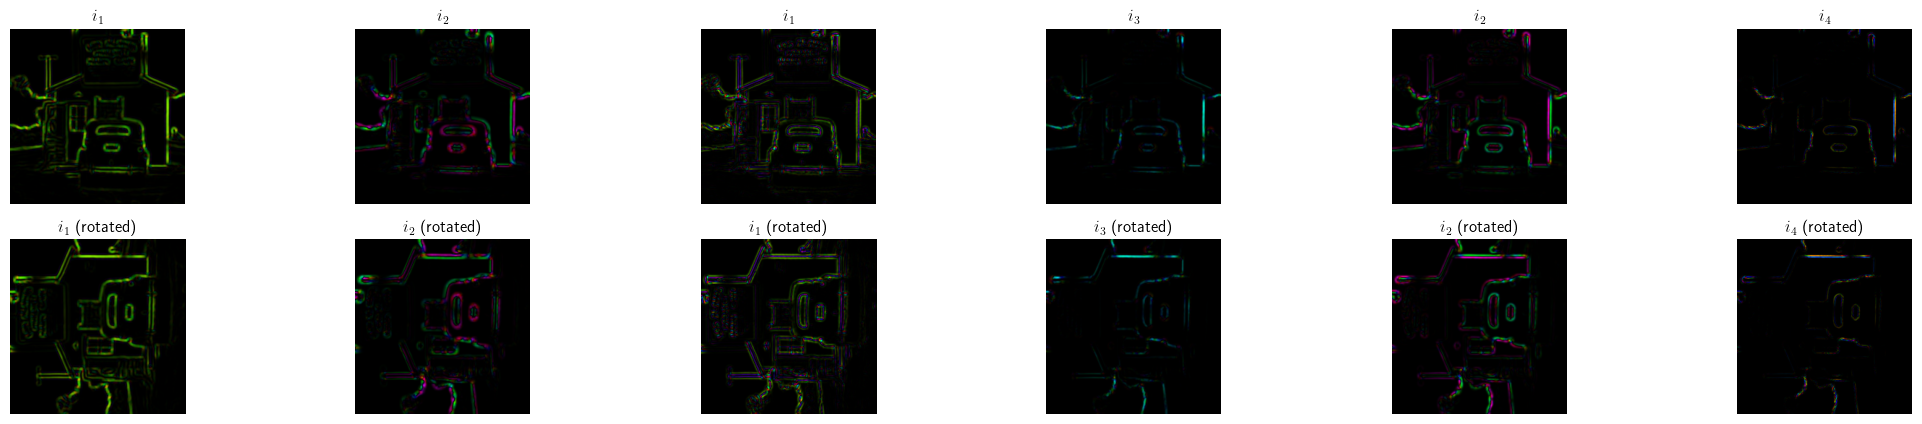

In [84]:
# plot invariants
fig, axs = plt.subplots(2, neg_invariants.shape[0], figsize=(26, 5))
for idx, ax in enumerate(axs[0].flat):
        ax.imshow(complex_to_rgb(neg_invariants[idx][OUTPUT_CHANNEL].detach().numpy()), cmap='hsv')
        ax.axis('off')
        ax.set_title(f'$i_{{{orders[idx+3]}}}$') 
for idx, ax in enumerate(axs[1].flat):
        ax.imshow(complex_to_rgb(neg_invariants_rot[idx][OUTPUT_CHANNEL].detach().numpy()), cmap='hsv')
        ax.axis('off')
        ax.set_title(f'$i_{{{orders[idx+3]}}}$ (rotated)')

# Assert the invariants are rotation invariant
assert torch.allclose(neg_invariants, torch.rot90(neg_invariants_rot, k=-1,dims=[-2, -1])), "Invariants are not rotation invariant"
# Asssert copies are also rotation invariant
assert torch.allclose(neg_invariants_copy, torch.rot90(neg_invariants_rot_copy, k=-1,dims=[-2, -1])), "Invariants with copy are not rotation invariant"

In [ ]:

from hippy2d.utils import get_default_complex
def init_radial_part(in_channels: int, out_channels: int, orders: List[int], ring_count: int):
    """
    Initializes the dict of weights

    Args:

        in_channels: input channels
        out_channels: output channels
        max_order: maximum rotation order from input and output
        ring_count (int): Number of rings for calculating the basis
    Returns:
        weights_dict: initialized dict of weights

    """
    weights = torch.zeros((len(orders), ring_count, in_channels, out_channels),
                            dtype=torch.get_default_dtype())
    for idx, _ in enumerate(orders):
        sh = [ring_count, in_channels, out_channels]
        # Initializes the weights using initialization method of He
        stddev = 0.4 * np.sqrt(2.0 / np.prod(sh[:3]))
        weights[idx] = torch.normal(torch.zeros(*sh), stddev)
    # Flat input & output channels
    return weights.view((len(orders), ring_count, in_channels * out_channels))

def get_angle_samples_count(kernel_size):
    return int(np.maximum(np.ceil(np.pi * kernel_size), 101))

def get_l2_neighbors(center, shape):
    lin = np.arange(shape) + 0.5
    jj, ii = np.meshgrid(lin, lin)
    ii = ii - center[1]
    jj = jj - center[0]
    return np.vstack((np.reshape(ii, -1), np.reshape(jj, -1)))

def get_interpolation_weights(fs, m, n_rings, angle_samples):
    """
    Used to construct the steerable filters using Radial basis functions.
    The filters are constructed on the patches of n_rings using Gaussian
    interpolation. (Code adapted from the tf code of Worrall et al., CVPR, 2017)

    Args:
        fs (int): filter size for the H-net convolutional layer
        m (int): max. rotation order for the steerable filters
        n_rings (int): No. of rings for the steerable filters
        angle_samples (int): No. of angle samples

    Returns:
        norm_weights (numpy): contains normalized weights for interpolation
        using the steerable filters
    """

    mid = int(np.floor(fs / 2))
    # Variance of Gaussian resampling
    std_gauss = (mid / n_rings) / 2
    # We define below radii up to n_rings-0.5 (as in Worrall et al, CVPR 2017)
    radii = np.linspace(m != 0, mid - 2 * std_gauss, n_rings)
    # We define pixel centers to be at positions 0.5
    center_pt = np.asarray([fs, fs]) / 2.

    # Extracting the set of angles to be sampled

    # Choosing the sampling locations for the rings
    lin = (2 * np.pi * np.arange(angle_samples)) / angle_samples
    ring_locations = np.vstack([-np.sin(lin), np.cos(lin)])

    # Create interpolation coefficient coordinates
    coords = get_l2_neighbors(center_pt, fs)

    # getting samples based on the chosen center_pt and the coords
    radii = radii[:, np.newaxis, np.newaxis, np.newaxis]
    ring_locations = ring_locations[np.newaxis, :, :, np.newaxis]
    diff = radii * ring_locations - coords[np.newaxis, :, np.newaxis, :]
    dist2 = np.sum(diff ** 2, axis=1)

    # Convert distances to weightings
    weights = np.exp(-0.5 * dist2 / (std_gauss ** 2))  # For bandwidth of 0.5

    # Normalizing the weights to calibrate the different steerable filters
    norm = np.sum(weights,
                    axis=2,
                    keepdims=True)
    assert np.all(norm != 0), "Normalizing by zero weights"
    return np.divide(weights,
                        norm,
                        where=(norm != 0)
                        )

def init_angular_part(kernel_size, orders, n_rings):
    N = get_angle_samples_count(kernel_size)
    weights2filter_sampler = []
    for order in orders:
        weights = get_interpolation_weights(kernel_size,
                                            m=order,
                                            n_rings=n_rings,
                                            angle_samples=N)
        low_pass_filter = np.dot(dft(N)[order, :], weights).T
        weights2filter_sampler.append(
                torch.from_numpy(low_pass_filter))
    return torch.stack(weights2filter_sampler)

class LearnableFlusser(torch.nn.Module):
    """ 
    Learnable Flusser layer as described in the notebook.
    """
    def __init__(self,
                 in_channels: int,
                 out_channels: int, 
                 max_order: int=4,
                 ring_count: int=3,
                 kernel_size: int=15,
                 norm_factor_function="copy"): # copy when rotating only the phase
        super(LearnableFlusser, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.max_order = max_order
        self.ring_count = ring_count
        self.kernel_size = kernel_size
        self.norm_factor_function = norm_factor_function
        self.complex_multiplier = 2

        orders = []
        # Centro-symmetric orders 
        symmetric_polynomials = 0
        for p in range(0, max_order//2 + 1):
            orders.append(0)
            symmetric_polynomials += 1
        non_symmetric_polynomials = 0
        # Non-symmetric orders starting with (0, 1)
        for p in range(0, max_order + 1):
            for q in range(0, min(max_order + 1-p, p + 1)):
                if p - q != 0:
                    orders.append(p - q)
                    non_symmetric_polynomials += 1
        self.symmetric_polynomials = symmetric_polynomials
        self.non_symmetric_polynomials = non_symmetric_polynomials
        self.register_buffer("orders", torch.tensor(orders, dtype=torch.int32))

        self.num_invariants = symmetric_polynomials + (non_symmetric_polynomials-1)*self.complex_multiplier + 1 # Minus one because of c_01 * c_10 is real
        # Init angular part that is fixed self.angular_part 
        # Note: This part can be also made learnable
        self.register_buffer("angular_part", init_angular_part(kernel_size, self.orders.tolist(), ring_count))
        # Init learnable radial part 
        self.weights = torch.nn.Parameter(init_radial_part(in_channels, out_channels, self.orders.tolist(), ring_count),
                                          requires_grad=True)
        # 1x1 real projection
        self.conv1x1 = torch.nn.Conv2d(in_channels=self.num_invariants * out_channels,
                                       out_channels=out_channels,
                                       kernel_size=1,
                                       dtype=torch.get_default_dtype())


    def forward(self, x):
        # Calculate the weights
        # TODO: Fix the complex dtype by replacing the dtype 
        x = x.to(get_default_complex())
        filters = rearrange(
            tensor=torch.matmul(self.angular_part, self.weights.to(get_default_complex())),
            pattern="o (h w) (ic oc) -> (o oc) ic h w",
            h=self.kernel_size,
            w=self.kernel_size,
            ic=self.in_channels,
            oc=self.out_channels)
        # Perform convolution 
        x = torch.conv2d(input=x,
                         weight=filters)
        x = rearrange(x, 'b (m out) h w -> b m out h w', m=len(self.orders))
        # symmetrics 
        symmetric = x[:, :self.symmetric_polynomials].real
        # moments 
        moments = x[:, self.symmetric_polynomials:]
        norm_factor = moments[:, 0].conj()
        # Compute invariants
        nonsymmetric = moments * torch.view_as_complex(
            complex_power_moivre(torch.view_as_real(norm_factor.resolve_conj()),
                                               self.orders[self.symmetric_polynomials:, None, None, None],
                                               magnitude_func=self.norm_factor_function)
        )
        diagonal = nonsymmetric[:, 0:1].real

        # Concatenate all parts to form the output
        x = torch.cat((symmetric, 
                       diagonal,
                       nonsymmetric[:, 1:].real,
                       nonsymmetric[:, 1:].imag), dim=1)
        x = rearrange(x, 'b m out h w -> b (m out) h w')
        x = self.conv1x1(x)
        # Return the output
        return x



In [ ]:
# Test invariance of the Learnable Flusser layer
invariant_layer = LearnableFlusser(in_channels=3, out_channels=2, max_order=4, ring_count=3, kernel_size=15)
# freeze
with torch.no_grad():
    for param in invariant_layer.parameters():
        param.requires_grad = False

inv = invariant_layer(test_rgb_img.unsqueeze(0))
inv_rot = invariant_layer(rotated_rgb_img.unsqueeze(0))

# Assert the invariants are rotation invariant
assert torch.allclose(inv, torch.rot90(inv_rot, k=-1,dims=[-2, -1])), "Invariants are not rotation invariant"
# TODO: Test the zeros